   ## Analysis of Red Wine Quality Dataset
   The aim of this portfolio is to explore the Red Wine Quality dataset and train models to see how accurately they predict quality from other features. You will also have to train classification models to predict quality. The Red WIne Quality data set displays multiple details about wine such as alcohol levels, different acidity levels, sugar levels and more.

In [46]:
#Library importation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

## Import Red Wine Quality Dataset

In [72]:
#data importation
df=pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## Data Exploration
* Check if there are any null values present in the dataset. If so, identify and remove them.

In [49]:
#check if there are any null values
nullcount = df.isna().sum()
nullcount

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## Conduct Data Analysis
You should code and display univariate and bivariate data analysis. What do you observe? Write an analysis.

<function matplotlib.pyplot.show(close=None, block=None)>

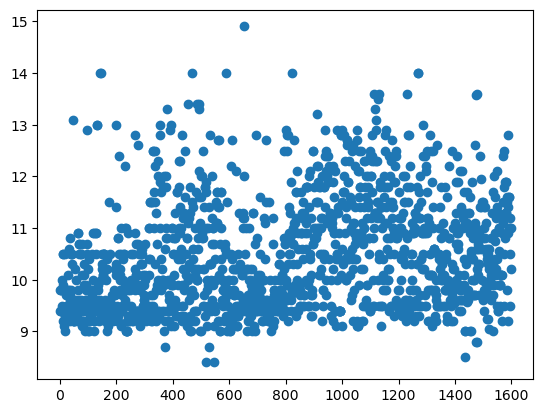

In [29]:
#Univariate Data Analysis
plt.scatter(df.index,df['alcohol'])
plt.show

In [ ]:
#ANALYSIS
#This scatter plot shows that there is large amounts of the sample that has an alcohol percentage of 13 and below, with only
#one point at 15%. The majority of the samples lie between 9-10% of alcohol. 

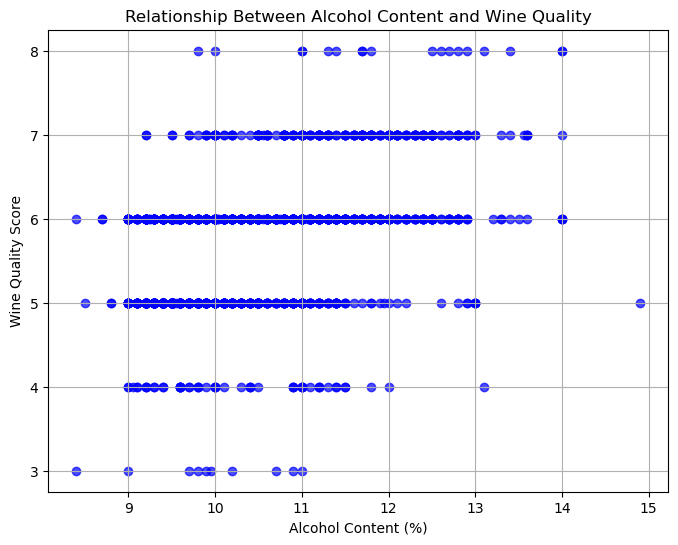

In [35]:
#Bivariate Data Analysis
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.scatter(df['alcohol'], df['quality'], color='blue', alpha=0.7)
plt.xlabel("Alcohol Content (%)")
plt.ylabel("Wine Quality Score")
plt.title("Relationship Between Alcohol Content and Wine Quality")
plt.grid(True)  # Add gridlines for better readability
plt.show()

In [73]:
#ANALYSIS
#This bivariate scatterplot shows the relationship between wine quality and alcohol content. The scatter plot shows that the
#majority of wine have a quality score of 6, and typially have an alcohol content of 9-13%. As the wine quality score increeases
#the alcohol percentage does not differ by much, as the quality score of 7 also has a majority alcohol content percentage 
#of 9-13%. Wine with a lower quality score (such as 3 and 4) typically do not have a large spread regarding alcohol percentage
#and are usually lower, ata rounf 8-12%. Higher wine quality socres, such as 8, are quite similar in nature. There is a smaller
#spread, however, the majority of Wines here have a higher quality score, being between 12-14%.

## Show the Correlations within the Dataset
* The end goal is to predict biodiesel against the some of the most correlated features regarding quality. Use the `corr()` method to display this.

In [37]:
#Check correlations
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [ ]:
#ANALYSIS
#The features with the highest correlation with quality are: alcohol, sulphates, citric acid and volatile acid.

## Splitting the Dataset into Training and Testing
* We need to randomly split the data into training sets and testing sets to help machine learning models make predictions. 
    * Split the data set into a training set:test set ratio of 8:2.

In [38]:
#training data containing 90% of the data
train_1, test_1 = train_test_split(df, test_size=0.2, random_state=142)
print(train_1.shape)
print(test_1.shape)




(1279, 12)
(320, 12)


## Train the Linear Regression Model
* To train a linear regression model, we need to select the two most correlated features for accurate results. Select the most appropriate features (no certain number) that work the best with quality.
* Once you have done that, train the linear regression models according to:
    * A. use the training/testing data and create a linear regression model with the selected correlated features
   

In [39]:
reg_1 = linear_model.LinearRegression()
X_train_1= train_1[['alcohol', 'sulphates']]
y_train_1 = train_1['quality']

X_test_1= test_1[['alcohol', 'sulphates']]
y_test_1 = test_1['quality']

reg_1.fit(X_train_1, y_train_1)

LinearRegression()

In [40]:

reg_2 = linear_model.LinearRegression()
X_train_2= train_1[['citric acid', 'volatile acidity']]
y_train_2 = train_1['quality']

X_test_2= test_1[['citric acid', 'volatile acidity']]
y_test_2 = test_1['quality']

reg_2.fit(X_train_2, y_train_2)

LinearRegression()

## Evaluate the Models
* Evaluate the models using the MSE and Root MSE. Print the results and write an analysis.

In [81]:
#Regression model A
predicted_1 = reg_1.predict(X_test_1)
mse_1 = ((np.array(y_test_1)-predicted_1)**2).sum()/len(y_test_1)
r2_2 = r2_score(y_test_1, predicted_1)
print("MSE:", mse_1)
print("R Squared:", r2_1)

MSE: 0.48439845311333124
R Squared: 0.27054219034390037


In [79]:
#ANALYSIS
#This regression model has an MSE of 0.484, indicating that it is predicting averagely and could be better. This could be due
#to the features not having a consdierably large correlation with quality, even though they are the highest out of all the 
#features. The r^2 value of 0.27 is considerably poor, as this implies that the model is only showing 0.27 (27%) of the 
#relationship. This may arise due to the same reason as the MSE, the strongest correlations with quality are quite weak.

In [80]:
#Regression Model B
predicted_2 = reg_2.predict(X_test_2)
mse_2 = ((np.array(y_test_2)-predicted_2)**2).sum()/len(y_test_2)
r2_2 = r2_score(y_test_2, predicted_2)
print("MSE:", mse_2)
print("R Squared:", r2_2)

MSE: 0.5507041813459134
R Squared: 0.1706920959157997


In [82]:
#ANALYSIS
#The average prediction made by this regression model (MSE = 0.55) suggests that it might be improved. This may be the 
#result of the characteristics, although being the highest among all the attributes, not having a noticeably strong link 
#with quality. Given that the model is only displaying 0.17 (or 21%) of the connection, the r^2 value of 0.17 is quite low. 
#This could be due to the greatest correlations with quality are rather small, which might be the same cause as the MSE.


## Visualise The Difference of the Predictions againt the Actual Values
* Use a histogram.

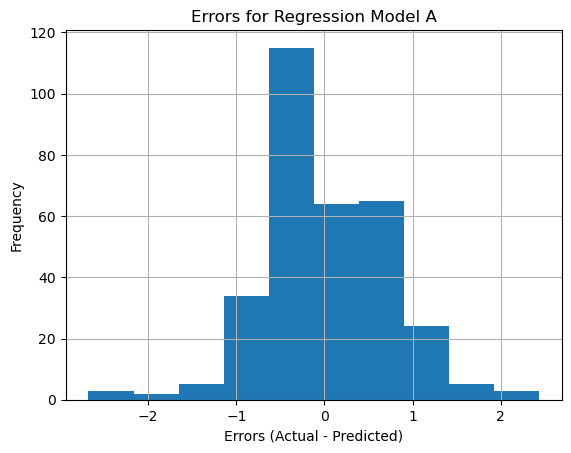

In [88]:
errors = y_test_1 - predicted_1
plt.hist(errors)
plt.xlabel("Errors (Actual - Predicted)") 
plt.ylabel("Frequency")  
plt.title("Errors for Regression Model A") 
plt.grid(True)  
plt.show()

In [83]:
#ANALYSIS
#The histogram displays the frequency of errors in the model, calculated by subtracting actual values from the predicted 
#value. The most errors are displayed at around the -1 - 0 range, emphasising that there is substantial underfitting present
#in the model. The frequncy is almost at 120. However, there is also a sufficient amount of errors at the 0 mark, depicting 
#that there are a few perfect predictions, at just over 60. Although, there is some overfitting present in the model, shown
#between 0 and 1. Therefore, this model needs to be improved which can be seen through the underfitting and overfitting. 

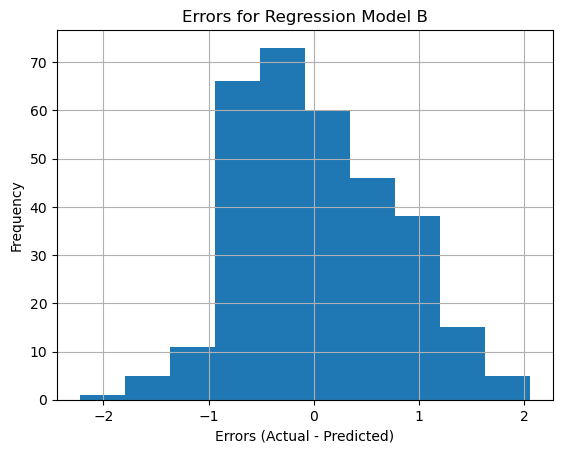

In [87]:
errors = y_test_2 - predicted_2
plt.hist(errors)
plt.xlabel("Errors (Actual - Predicted)") 
plt.ylabel("Frequency")  
plt.title("Errors for Regression Model B") 
plt.grid(True)  
plt.show()

In [85]:
#ANALYSIS
#The histogram displays errors mostly displayed between 0 and -1. There are bwteen 65-75 instances of errors on this range, 
#depicting underfitting in the model. However, it is not severe as there are below 5 instances at the -2 range. There are
#also 60 times where the model predicted perfectly, which can be seen at the 0 mark. Although, there is substantial overfitting
#present in the model as there is high amounts of errors seen between 0 and 1. Hence, the model is predicting perfectly at 
#times, however, there is still some underfitting and overfitting present.

## Train a KNN Model
*  Predict Quality by training a KNN Model based on the selected features. Calculate the accuracy of this model and write an analysis

In [44]:
#Question 5 - Training the KNN Model and calculate the accuracy

X = df[['alcohol', 'sulphates', 'citric acid', 'volatile acidity']]
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

y_train_prediction = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_prediction)

y_test_prediction = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_prediction)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)



Training Accuracy: 0.6966379984362784
Test Accuracy: 0.59375


In [ ]:
#ANALYSIS
#The training accuracy of 0.6966 (can be seen as 70%) indicates that the model can display 70% of the points within the 
#training set correctlt. This emphasises that the model is capable of studying some of the relationships in the model between
#quality and the other features. The testing accuracy of 0.59 indiactes that the models does not perform as well when 
#osberving unseen data within the test set. The difference between the training and testing set is 0.1, suggesting that 
#there is problems with overfitting within the model. 